In [1]:
import json_tricks
answer = {}

# Gradient descent:

Here is a theory:
- The gradient of the loss function with respect to the weights $\nabla_{\mathbf x} L$ points to the direction of the fastest ascent.
- Thus, we need to perform steps in the opposite direction.
- Here is the gradient descent algorithm:
$\mathbf w^{t+1} = \mathbf w^{t} - \alpha \nabla_{\mathbf w} L$

# Finding gradient with Torch

PyTorch knows how to calculate the derivative of a value with respect to all the tensors that were used to produce it.
To do so, we have to calculate this value (usually the loss function), and then call its `backward` method.

Here is how it is done:
```python
x = torch.tensor(10, requires_grad=True)
y = torch.tensor(5, requires_grad=True)
loss = x + y
loss.backward()

print(x.grad)
print(y.grad)
```

The output should be 1 and 1 because if $L = x + y$, then $\partial_x L = 1$ and $\partial_y L = 1$

The `requires_grad` parameter indicates that it is necessary to calculate the gradient for this value (that probably is obvious, but still important).

Note that before you perform backpropagation, the gradient is equal to `None` indicating that it is not initialized and cannot be used.

In [2]:
import torch

x = torch.tensor(10., requires_grad=True)
y = torch.tensor(5., requires_grad=True)

loss = x + y
loss.backward()

answer['x_grad'] = x.grad.clone().numpy()
answer['y_grad'] = y.grad.clone().numpy()

print('dL/dx:', x.grad)
print('dL/dy:', y.grad)

dL/dx: tensor(1.)
dL/dy: tensor(1.)


# Something more sophisticated

In the next task we will calculate something slightly more sophisticated. We will calculate gradient for the value

$f(X) = 10\cdot\sum\limits_{i, j}x_{ij}^2$

Our task is to find

$\partial_X f(X)$

Theoretically, it is equal to:

$\partial_{x_{kl}} f(X) = \Big( 10\cdot\sum\limits_{i, j}x_{ij}^2\Big)_{x_{kl}}' = 10 \cdot\Big(\sum\limits_{i, j}x_{ij}^2\Big)_{x_{kl}}' $

$ \quad = 10 \cdot\sum\limits_{i, j}\Big(x_{ij}^2\Big)_{x_{kl}}' $

$ \quad = 10 \cdot\sum\limits_{i, j}2 x_{ij} \big(x_{ij}\big)_{x_{kl}}' $


$ \quad = 10 \cdot 2 x_{kl} \cdot 1 = 20 x_{kl} $

Hence, the theoretical derivative is:

$f(X) = 10\cdot\sum\limits_{i, j}x_{ij}^2$

$\partial_X f(X) = 20 X $

Let us try to calculate the result using Torch:

In [6]:
import torch

X = torch.tensor(
    [[1.,  2.,  3.,  4.],
     [5.,  6.,  7.,  8.],
     [9., 10., 11., 12.]], requires_grad=True)

function = 10 * torch.sum(X ** 2)# this is an example
## YOUR CODE HERE ##

function.backward()


answer['X_grad'] = X.grad.clone().numpy()
print(X.grad, '<- gradient')

tensor([[ 20.,  40.,  60.,  80.],
        [100., 120., 140., 160.],
        [180., 200., 220., 240.]]) <- gradient


# Function order

In PyTorch, you can visualize the order of the functions in the graph. An example is below.

In [7]:
print(function.grad_fn)
print(function.grad_fn.next_functions[0][0])
print(function.grad_fn.next_functions[0][0].next_functions[0][0])
print(function.grad_fn.next_functions[0][0].next_functions[0][0].next_functions[0][0])

# Some visualization functions

This function will be useful for seeing the contours of the function.

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def show_contours(objective,
                  x_lims=[-10.0, 10.0], 
                  y_lims=[-10.0, 10.0],
                  x_ticks=100,
                  y_ticks=100):
    x_step = (x_lims[1] - x_lims[0]) / x_ticks
    y_step = (y_lims[1] - y_lims[0]) / y_ticks
    X, Y = np.mgrid[x_lims[0]:x_lims[1]:x_step, y_lims[0]:y_lims[1]:y_step]
    res = []
    for x_index in range(X.shape[0]):
        res.append([])
        for y_index in range(X.shape[1]):
            x_val = X[x_index, y_index]
            y_val = Y[x_index, y_index]
            res[-1].append(objective(np.array([[x_val, y_val]]).T))
    res = np.array(res)
    plt.figure(figsize=(7,7))
    plt.contour(X, Y, res, 100)
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')

# Programming the Gradient Descent

We will start with optimizing a simple function:

$f(x, y) = 10 (x^2 + y^2)$

It is a good function to start with because it has a minimum at the point $(0, 0)$. We should see convergence toward that point.

## The Task
- code the function `function_parabola` that calculates the objective function.
- code the gradient descent step with $\alpha = 0.001$. For that:
    - calculate the objective function value
    - perform backpropagation
    - perform a correct update of `X.data`
    - zero the gradient of `X` using `X.grad.zero_()`

In [13]:
import torch

x = torch.tensor(
    [8., 8.], requires_grad=True)

var_history = []
fn_history = []

def function_parabola(X):
    if isinstance(X, torch.Tensor):
        return 10 * torch.sum(X ** 2)

    X = torch.tensor(X, dtype=torch.float32)
    res = 10 * torch.sum(X ** 2)
    return res.item()

def make_gradient_step(function, X):
    alpha = 0.001

    loss = function(X)
    loss.backward()

    with torch.no_grad():
        X.data = X.data - alpha * X.grad

    X.grad.zero_()

for i in range(500):
    var_history.append(x.data.cpu().numpy().copy())
    fn_history.append(function_parabola(x).data.cpu().numpy().copy())
    make_gradient_step(function_parabola, x)

answer['var_history_1'] = var_history
answer['fn_history_1'] = fn_history

# Some visualizations

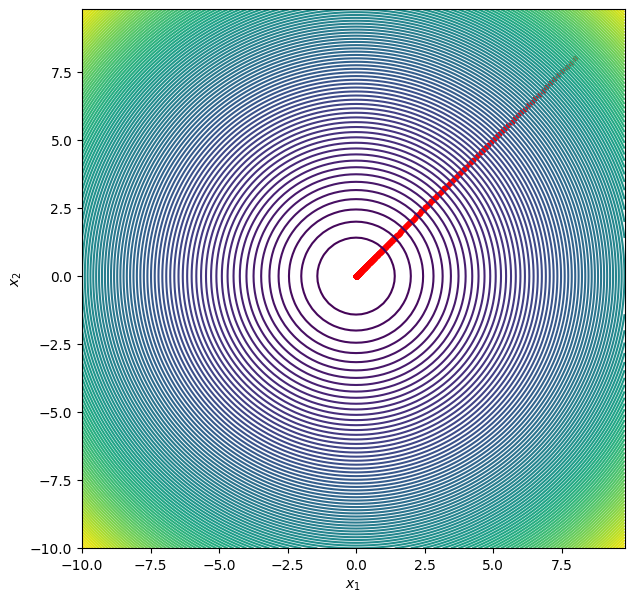

In [14]:
show_contours(function_parabola)
plt.scatter(np.array(var_history)[:,0], np.array(var_history)[:,1], s=10, c='r');

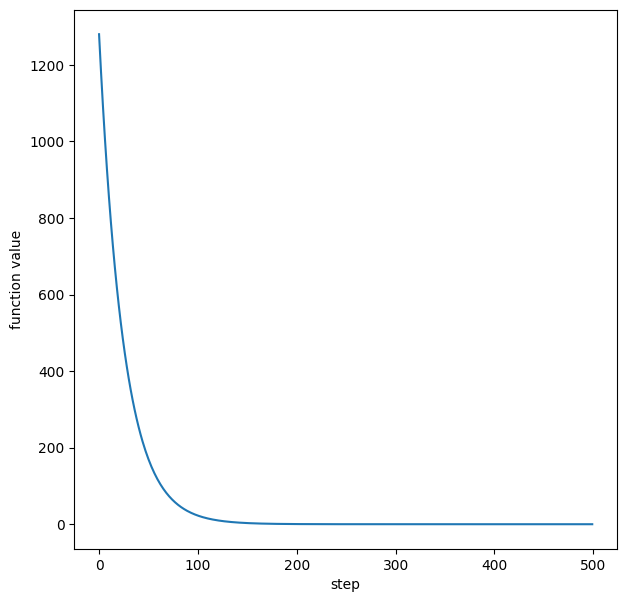

In [15]:
plt.figure(figsize=(7,7))
plt.plot(fn_history);
plt.xlabel('step')
plt.ylabel('function value');

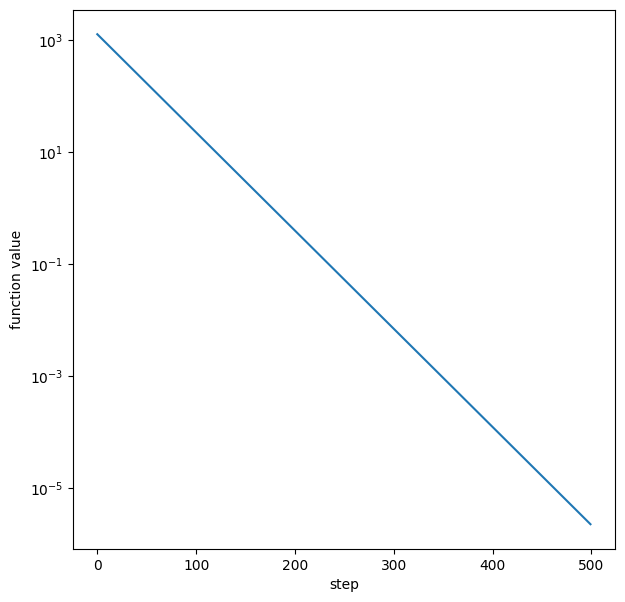

In [16]:
plt.figure(figsize=(7,7))
plt.semilogy(fn_history);
plt.xlabel('step')
plt.ylabel('function value');

# Optimizing a slightly more sophisticated function

Below is another function `function_skewed`. Perform its optimization using the gradient descent that you have coded above.

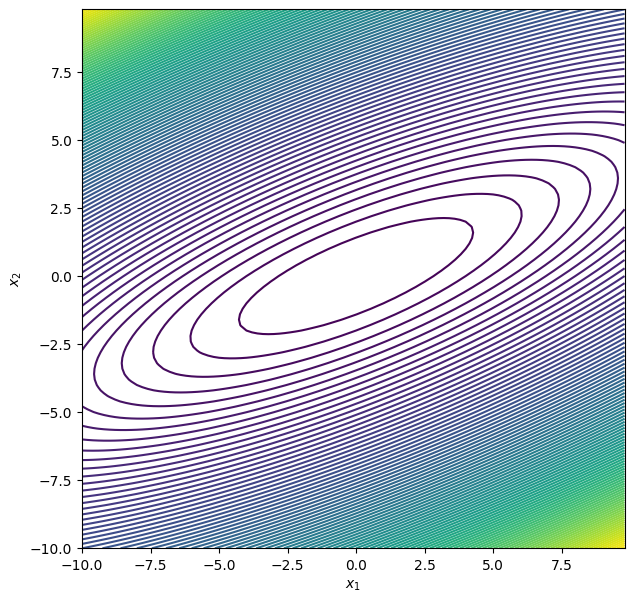

In [17]:
def function_skewed(variable):
    gramma = torch.tensor([[1., -1.], [1., 1.]]) @ torch.tensor([[1.0, 0.0], [0.0, 4.0]])
    res = 10 * (variable.unsqueeze(0) @ (gramma @ variable.unsqueeze(1))).sum()
    return res

def function_skewed_np(variable):
    gramma = np.array([[1, -1], [1, 1]]) @ np.array([[1.0, 0.0], [0.0, 4.0]])
    res = 10 * (variable.transpose(1, 0) @ (gramma @ variable)).sum()
    return res

show_contours(function_skewed_np)

In [18]:
x = torch.tensor(
    [8., 8.], requires_grad=True)
var_history = []
fn_history = []

for i in range(500):
    var_history.append(x.data.cpu().numpy().copy())
    fn_history.append(function_skewed(x).data.cpu().numpy().copy())
    make_gradient_step(function_skewed, x)

answer['var_history_2'] = var_history
answer['fn_history_2'] = fn_history

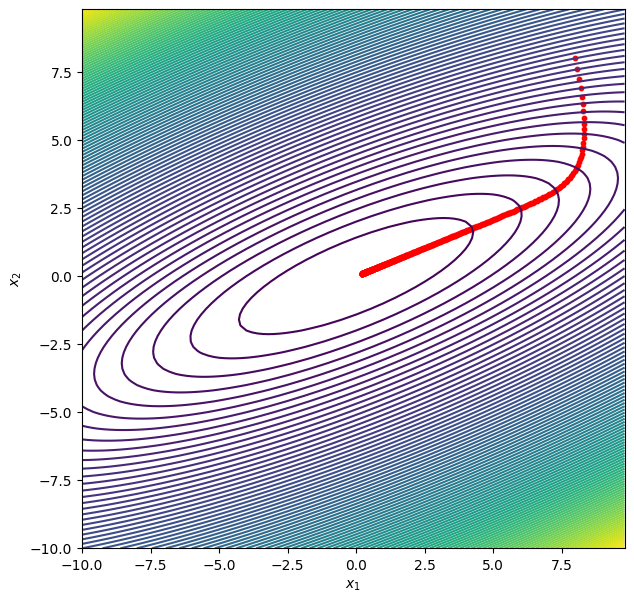

In [19]:
show_contours(function_skewed_np)
plt.scatter(np.array(var_history)[:,0], np.array(var_history)[:,1], s=10, c='r');

# How to use this

Now you can find the minimum of rather sophisticated functions.

# PyTorch Optimizers

PyTorch has an `optim` package that contains a lot of interesting optimizers. The most widely used ones are:
- SGD
- AdamW

We will study the differences between the optimizers a bit later, nevertheless, you can use them both with the functions above.

Below your task is to: 
- create an optimizer `SGD` with learning rate 0.001. This optimizer should optimize variable `x`
- optimize the function `function_skewed` with it with the following steps:
    1. zero the optimizer's gradients (in case you do not do that, the gradients will accumulate)
    2. calculate function value
    2. backpropagate the gradient
    3. make optimization step



In [20]:
x = torch.tensor(
    [8., 8.], requires_grad=True)
var_history = []
fn_history = []

optimizer = torch.optim.SGD([x], lr=0.001)

for i in range(500):
    optimizer.zero_grad()
    
    function_result = function_skewed(x)
    function_result.backward()
    
    optimizer.step()
    
    var_history.append(x.data.cpu().numpy().copy())
    fn_history.append(function_result.data.cpu().numpy().copy())

answer['var_history_3'] = var_history
answer['fn_history_3'] = fn_history


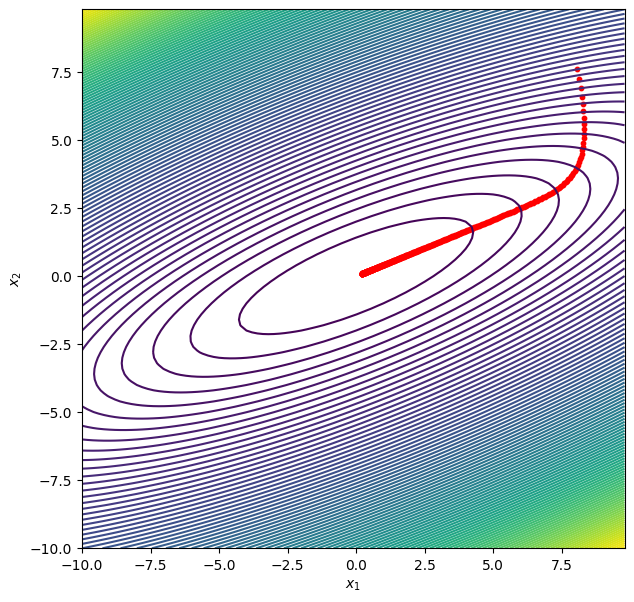

In [21]:
show_contours(function_skewed_np)
plt.scatter(np.array(var_history)[:,0], np.array(var_history)[:,1], s=10, c='r');

Lastly, here you should create `AdamW` optimizer with learning rate `1`.
Perform the same steps in the optimization cycle

In [22]:
x = torch.tensor(
    [8., 8.], requires_grad=True)
var_history = []
fn_history = []

optimizer = torch.optim.AdamW([x], lr=1)

## YOUR CODE HERE ##

for i in range(500):
    ## YOUR CODE HERE ##
    optimizer.zero_grad()
    
    function_result = function_skewed(x)
    function_result.backward()
    
    optimizer.step()    
    var_history.append(x.data.cpu().numpy().copy())
    fn_history.append(function_result.data.cpu().numpy().copy())

answer['var_history_4'] = var_history
answer['fn_history_4'] = fn_history


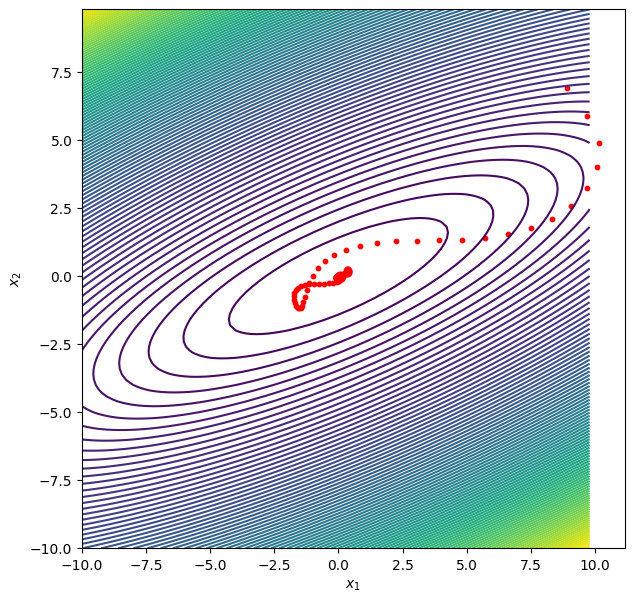

In [23]:
show_contours(function_skewed_np)
plt.scatter(np.array(var_history)[:,0], np.array(var_history)[:,1], s=10, c='r');

# Other optimizers

There are other optimizers in the PyTorch `optim` package, but they are almost never used. 

You can even code your own optimizer if you dare.

Nevertheless, the most widely used optimizer and kind of a default choice for any network is Adam.

# Conclusion

Now you know how to do optimization with PyTorch.

In [24]:
json_tricks.dump(answer, '.answer.json')

'{"x_grad": {"__ndarray__": 1.0, "dtype": "float32", "shape": []}, "y_grad": {"__ndarray__": 1.0, "dtype": "float32", "shape": []}, "X_grad": {"__ndarray__": [[20.0, 40.0, 60.0, 80.0], [100.0, 120.0, 140.0, 160.0], [180.0, 200.0, 220.0, 240.0]], "dtype": "float32", "shape": [3, 4], "Corder": true}, "var_history_1": [{"__ndarray__": [8.0, 8.0], "dtype": "float32", "shape": [2]}, {"__ndarray__": [7.840000152587891, 7.840000152587891], "dtype": "float32", "shape": [2]}, {"__ndarray__": [7.683200359344482, 7.683200359344482], "dtype": "float32", "shape": [2]}, {"__ndarray__": [7.529536247253418, 7.529536247253418], "dtype": "float32", "shape": [2]}, {"__ndarray__": [7.378945350646973, 7.378945350646973], "dtype": "float32", "shape": [2]}, {"__ndarray__": [7.2313666343688965, 7.2313666343688965], "dtype": "float32", "shape": [2]}, {"__ndarray__": [7.0867390632629395, 7.0867390632629395], "dtype": "float32", "shape": [2]}, {"__ndarray__": [6.945004463195801, 6.945004463195801], "dtype": "flo